# Kalix speed results — analysis

Plots the long-term performance database (`speed_results.csv`) written by
`run_speed_tests.py`. Tests are discovered from the database — nothing here
is hardcoded to the current suite.

**How to read these numbers**
- The comparator is always the **min** of repeated runs — least contaminated by OS noise.
- The x-axis is the **benchmark run** (ordinal), ordered by commit date: real
  calendar spacing between benchmark runs is information-free and makes the
  charts unreadable. Each tick shows the commit sha (* = dirty tree), kalix
  version, and commit date. Same-commit re-runs get their own positions, so
  experiments at one sha remain visible as a progression.
- Numbers are only comparable **within one machine**. The timeline shows one
  line per hostname; all other figures are pinned to `HOST`.
- Hollow markers are runs from a **dirty working tree** (`commit_dirty=true`).

Re-run all cells after adding new results.

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("speed_results.csv", parse_dates=["test_date"])
df["commit_date"] = pd.to_datetime(df["commit_date"], utc=True, format="ISO8601")
df = df.sort_values(["commit_date", "test_date"])

# Charts plot against an ordinal "benchmark run" axis, ordered by commit_date
# (then test_date for same-commit re-runs): calendar spacing between benchmark
# runs is information-free and makes the charts unreadable. Each run keeps its
# commit sha, version, and commit date as the tick label.
runs = (df[["commit_date", "test_date", "commit_sha", "commit_dirty", "kalix_version"]]
        .drop_duplicates(subset=["commit_date", "test_date"])
        .sort_values(["commit_date", "test_date"])
        .reset_index(drop=True))
runs["run_id"] = runs.index + 1
runs["run_label"] = runs.apply(
    lambda r: f"{r.commit_sha}{'*' if r.commit_dirty else ''}\n"
              f"v{r.kalix_version}\n{r.commit_date:%d %b %y}", axis=1)
df = df.merge(runs[["commit_date", "test_date", "run_id"]],
              on=["commit_date", "test_date"])

def apply_run_axis(ax, max_ticks=14):
    """Ordinal benchmark-run axis with sha/version/date tick labels,
    thinned automatically once the database outgrows max_ticks."""
    step = max(1, math.ceil(len(runs) / max_ticks))
    ticks = runs.run_id[::step]
    ax.set_xticks(ticks, runs.run_label[::step], fontsize=7.5)
    ax.set_xlim(0.5, len(runs) + 0.5)

# Colour follows the entity, forever: each test keeps the palette slot it got
# on FIRST APPEARANCE in the database (append-only, so this never reshuffles;
# adding a test later never repaints the existing ones).
PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
           "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
TESTS = list(df.drop_duplicates("test_name")["test_name"])
if len(TESTS) > len(PALETTE):
    print(f"WARNING: {len(TESTS)} tests but only {len(PALETTE)} palette slots - "
          "fold old tests or extend the palette deliberately.")
TEST_COLOURS = {t: PALETTE[i % len(PALETTE)] for i, t in enumerate(TESTS)}

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e8e8e6"
LINESTYLES = ["solid", (0, (4, 2)), (0, (1, 1)), (0, (6, 2, 1, 2))]  # per hostname

def style_axes(ax, title=None):
    """House style: recessive grid and axes, text in ink tokens."""
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK_2, labelsize=9)
    if title:
        ax.set_title(title, loc="left", fontsize=11, color=INK)

# Cross-machine numbers are not comparable: single-machine figures use HOST
# (default: the most recently used machine).
HOST = df.sort_values("test_date")["hostname"].iloc[-1]
print(f"tests: {TESTS}")
print(f"hosts: {list(df.hostname.unique())} | single-machine plots use: {HOST}")
df.tail(3)

tests: ['1_sacramento_long', '2_unregulated_users', '3_unregulated_users_with_functions', '4_regulated_system']
hosts: ['Chass-MacBook-Air.local'] | single-machine plots use: Chass-MacBook-Air.local


,test_date,commit_sha,commit_dirty,commit_date,kalix_version,user,hostname,os,cpu_class,rustc_version,test_name,repeats,sim_min_ms,sim_median_ms,sim_sd_ms,load_min_ms,output_min_ms,total_min_ms,run_id
41,2026-07-03 13:25:12,cfa6860,True,2026-07-03 02:59:39+00:00,0.3.3,chas,Chass-MacBook-Air.local,Darwin 25.3.0 arm64,Apple M1,rustc 1.96.0 (ac68faa20 2026-05-25),3_unregulated_users_with_functions,7,85.3,86.0,13.66,15.9,37.9,139.7,14
42,2026-07-03 13:25:13,cfa6860,True,2026-07-03 02:59:39+00:00,0.3.3,chas,Chass-MacBook-Air.local,Darwin 25.3.0 arm64,Apple M1,rustc 1.96.0 (ac68faa20 2026-05-25),1_sacramento_long,15,6.4,6.5,0.11,53.8,56.5,117.0,15
43,2026-07-03 13:36:52,c6e418a,True,2026-07-03 03:25:49+00:00,0.3.3,chas,Chass-MacBook-Air.local,Darwin 25.3.0 arm64,Apple M1,rustc 1.96.0 (ac68faa20 2026-05-25),1_sacramento_long,15,6.3,6.4,0.06,53.7,56.7,117.2,16


## Simulation time over code history, per test

Small multiples, one line per machine (linestyle = hostname; colour stays with
the test). Each test has its own zero-based scale. Hollow markers = dirty
working tree.

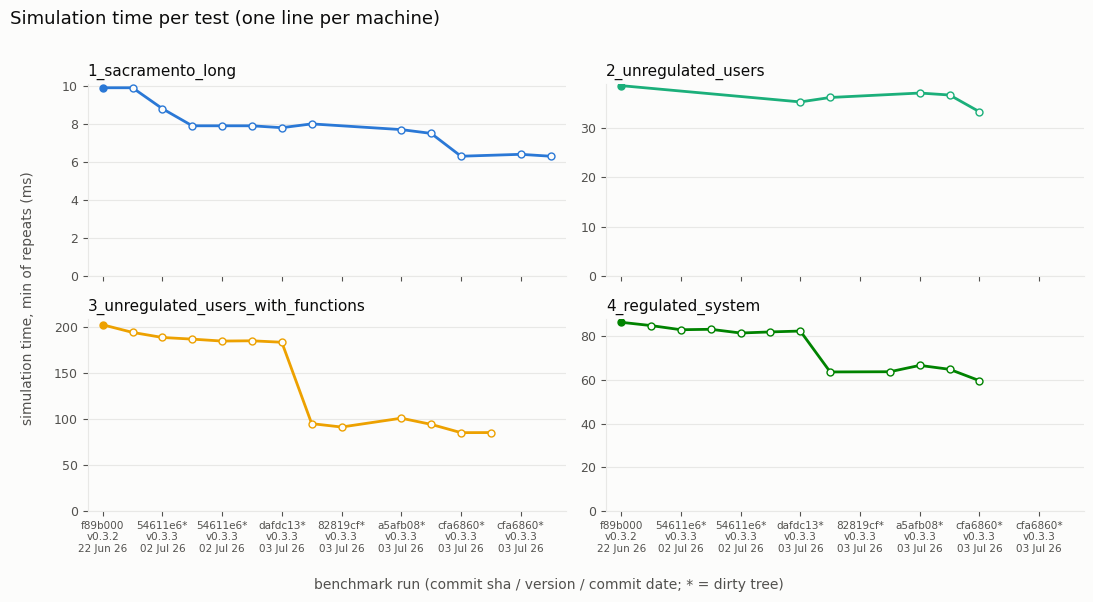

In [2]:
n_rows = math.ceil(len(TESTS) / 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 3 * n_rows), facecolor=SURFACE,
                         sharex=True, squeeze=False)
hostnames = sorted(df.hostname.unique())

for ax in axes.flat[len(TESTS):]:
    ax.set_visible(False)

for ax, test in zip(axes.flat, TESTS):
    colour = TEST_COLOURS[test]
    d = df[df.test_name == test]
    style_axes(ax, test)
    for h_idx, host in enumerate(hostnames):
        dh = d[d.hostname == host]
        if dh.empty:
            continue
        ax.plot(dh.run_id, dh.sim_min_ms, color=colour, linewidth=2,
                linestyle=LINESTYLES[h_idx % len(LINESTYLES)], zorder=2)
        clean = dh[dh.commit_dirty == False]
        dirty = dh[dh.commit_dirty == True]
        ax.plot(clean.run_id, clean.sim_min_ms, "o", color=colour, markersize=5, zorder=3)
        ax.plot(dirty.run_id, dirty.sim_min_ms, "o", markerfacecolor=SURFACE,
                markeredgecolor=colour, markersize=5, zorder=3)
    ax.set_ylim(bottom=0)
    apply_run_axis(ax)

# Hostname -> linestyle legend (grey: identity is the linestyle, colour stays
# with the test). Skipped while the database has a single machine.
if len(hostnames) > 1:
    from matplotlib.lines import Line2D
    handles = [Line2D([], [], color=INK_2, linewidth=2,
                      linestyle=LINESTYLES[i % len(LINESTYLES)], label=h)
               for i, h in enumerate(hostnames)]
    fig.legend(handles=handles, frameon=False, fontsize=9, labelcolor=INK_2,
               ncols=min(len(hostnames), 3), loc="upper right")

fig.supxlabel("benchmark run (commit sha / version / commit date; * = dirty tree)",
             fontsize=10, color=INK_2)
fig.supylabel("simulation time, min of repeats (ms)", fontsize=10, color=INK_2)
fig.suptitle("Simulation time per test (one line per machine)", x=0.01, ha="left",
             fontsize=13, color=INK)
fig.tight_layout(rect=(0.01, 0, 1, 0.97))
plt.show()

## Drift, indexed to the current implementation (latest commit = 100)

All tests on one honest axis, normalised so **today = 100**: a point at 150
means that commit was 50% slower than the current code. The reference renews
itself every time results are added — unlike an ever-more-irrelevant oldest
baseline. A future regression shows as the right-hand end climbing above the
dashed line.

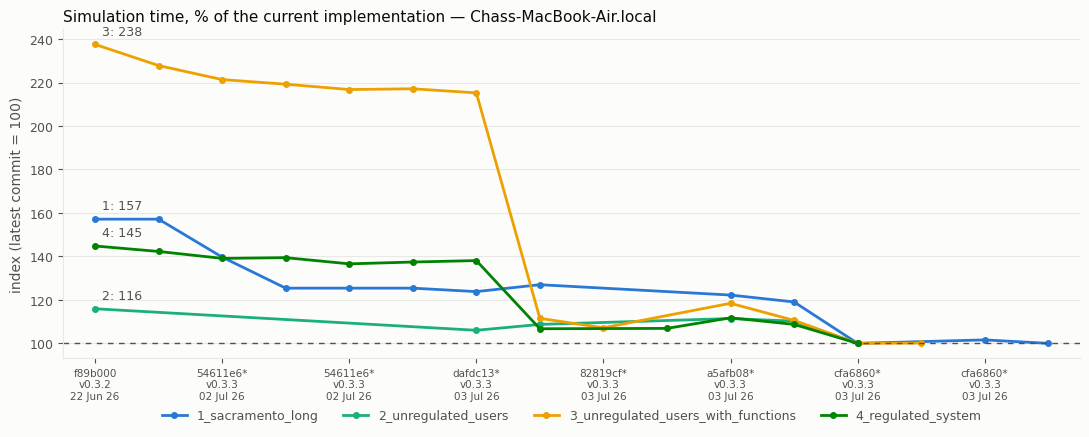

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5), facecolor=SURFACE)
style_axes(ax, f"Simulation time, % of the current implementation — {HOST}")

for test in TESTS:
    colour = TEST_COLOURS[test]
    d = df[(df.test_name == test) & (df.hostname == HOST)]
    if d.empty:
        continue
    # Reference: the min across the newest commit's measurements (noise-robust)
    newest = d[d.commit_date == d.commit_date.max()]
    current = newest.sim_min_ms.min()
    indexed = d.sim_min_ms / current * 100
    ax.plot(d.run_id, indexed, color=colour, linewidth=2,
            marker="o", markersize=4, label=test)
    # Direct label at the line START (the ends all converge on 100)
    ax.annotate(f"{test.split('_')[0]}: {indexed.iloc[0]:.0f}",
                (d.run_id.iloc[0], indexed.iloc[0]), xytext=(5, 7),
                textcoords="offset points", fontsize=9, color=INK_2, ha="left")

ax.axhline(100, color=INK_2, linewidth=1, linestyle=(0, (4, 4)))
apply_run_axis(ax)
ax.set_ylabel("index (latest commit = 100)", fontsize=10, color=INK_2)
ax.legend(frameon=False, fontsize=9, labelcolor=INK_2,
          ncols=len(TESTS), loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

## Where the time goes now — per-phase breakdown of the latest run

Load / simulate / write-output per test, latest run on this machine. This is
the chart that says where the next optimisation effort should aim.

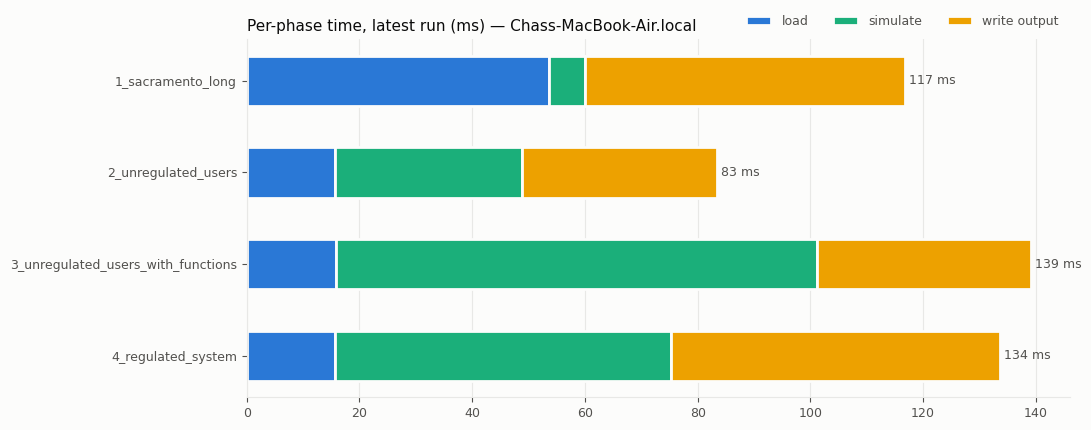

In [4]:
latest = (df[df.hostname == HOST].sort_values(["commit_date", "test_date"])
            .groupby("test_name").tail(1).set_index("test_name").loc[TESTS])

PHASES = [("load_min_ms", "load", "#2a78d6"),
          ("sim_min_ms", "simulate", "#1baf7a"),
          ("output_min_ms", "write output", "#eda100")]

fig, ax = plt.subplots(figsize=(11, 0.9 * len(TESTS) + 0.8), facecolor=SURFACE)
style_axes(ax, f"Per-phase time, latest run (ms) — {HOST}")
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.grid(axis="y", visible=False)

y = range(len(latest))
left = pd.Series(0.0, index=latest.index)
for col, label, colour in PHASES:
    ax.barh(y, latest[col], left=left, height=0.55, color=colour, label=label,
            edgecolor=SURFACE, linewidth=2)  # 2px surface gap between segments
    left += latest[col]

for i, (name, total) in enumerate(left.items()):
    ax.annotate(f" {total:.0f} ms", (total, i), fontsize=9, color=INK_2, va="center")

ax.set_yticks(list(y), latest.index, fontsize=9)
ax.invert_yaxis()
ax.legend(frameon=False, fontsize=9, labelcolor=INK_2, ncols=3,
          loc="lower right", bbox_to_anchor=(1, 1.0))
fig.tight_layout()
plt.show()

## The expression-cost instrument

Tests 2 and 3 are the same network — test 2 with scalar demands, test 3 with
pump/threshold expressions. Their difference isolates the cost of DynamicInput
expression evaluation. (Skipped automatically if either test leaves the
database.)

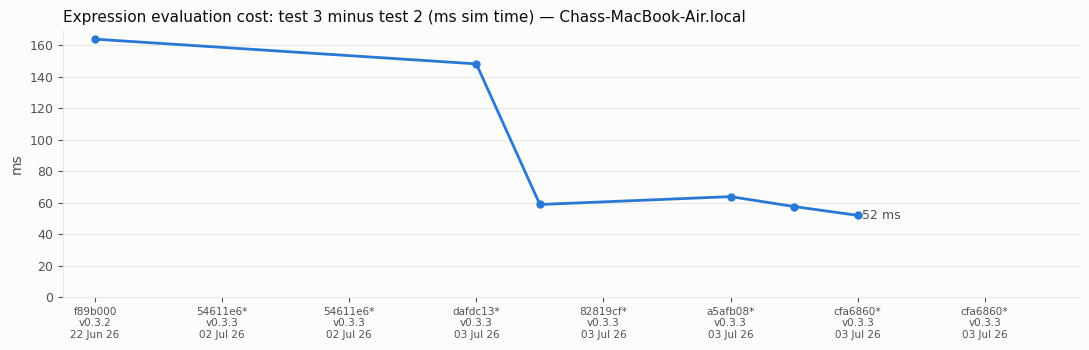

In [5]:
CONTROL, WITH_FUNCS = "2_unregulated_users", "3_unregulated_users_with_functions"

if {CONTROL, WITH_FUNCS} <= set(TESTS):
    wide = (df[df.hostname == HOST]
            .pivot_table(index="run_id", columns="test_name", values="sim_min_ms", aggfunc="min")
            .dropna(subset=[CONTROL, WITH_FUNCS]))
    overhead = wide[WITH_FUNCS] - wide[CONTROL]

    fig, ax = plt.subplots(figsize=(11, 3.6), facecolor=SURFACE)
    style_axes(ax, f"Expression evaluation cost: test 3 minus test 2 (ms sim time) — {HOST}")
    ax.plot(overhead.index, overhead.values, color="#2a78d6", linewidth=2,
            marker="o", markersize=5)
    ax.annotate(f" {overhead.iloc[-1]:.0f} ms", (overhead.index[-1], overhead.iloc[-1]),
                fontsize=9, color=INK_2, va="center")
    ax.set_ylim(bottom=0)
    ax.set_ylabel("ms", fontsize=10, color=INK_2)
    apply_run_axis(ax)
    fig.tight_layout()
    plt.show()
else:
    print("Instrument tests not both present in the database - skipped.")

## Summary table — oldest vs latest, per test

The table view (also the accessibility fallback for the charts above).

In [6]:
def first_last(group):
    group = group.sort_values(["commit_date", "test_date"])
    first, last = group.iloc[0], group.iloc[-1]
    return pd.Series({
        "oldest commit": str(first.commit_date.date()),
        "sim oldest (ms)": first.sim_min_ms,
        "sim latest (ms)": last.sim_min_ms,
        "sim change": f"{(last.sim_min_ms / first.sim_min_ms - 1) * 100:+.0f}%",
        "load latest (ms)": last.load_min_ms,
        "output latest (ms)": last.output_min_ms,
        "latest commit": last.commit_sha,
    })

df[df.hostname == HOST].groupby("test_name").apply(first_last, include_groups=False)

,oldest commit,sim oldest (ms),sim latest (ms),sim change,load latest (ms),output latest (ms),latest commit
test_name,,,,,,,
1_sacramento_long,2026-06-22,9.9,6.3,-36%,53.7,56.7,c6e418a
2_unregulated_users,2026-06-22,38.6,33.3,-14%,15.6,34.5,cfa6860
3_unregulated_users_with_functions,2026-06-22,202.4,85.3,-58%,15.9,37.9,cfa6860
4_regulated_system,2026-06-22,86.3,59.6,-31%,15.7,58.3,cfa6860
